<a href="https://colab.research.google.com/github/Savage-Soccer/multilingual-clip-audit/blob/main/clip_spectral_alignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spectral Alignment for Multilingual CLIP — Part 2
### Can we fix the geometry post-hoc without retraining?

**Motivation:** Phase 3 showed that non-English text embedding spaces are
geometrically incompatible with the image space. The Procrustes disparity
for Hindi is 0.886 — near maximum. But Procrustes also tells us the
**optimal rotation** that would best align the spaces.

**Key idea:** If we learn that rotation from training pairs and apply it
at inference time, we might fix the geometry without touching the model.

**Three alignment levels:**
- **Level 1 — Procrustes:** Learn optimal rotation from Hindi -> English space
- **Level 2 — Direct:** Learn rotation from Hindi text -> Image space directly  
- **Level 3 — Linear Projection:** Learn full linear map (rotation + scale + translation)

**No GPU needed. No retraining. Pure linear algebra on saved embeddings.**

## 1. Imports

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes
from scipy.spatial import procrustes as scipy_procrustes
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('All imports ready — no GPU needed for this notebook')

All imports ready — no GPU needed for this notebook


## 2. Mount Drive and Load Embeddings

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR   = '/content/drive/MyDrive/clip_audit'
PHASE2_DIR = os.path.join(BASE_DIR, 'phase2')
ALIGN_DIR  = os.path.join(BASE_DIR, 'spectral_alignment')
os.makedirs(ALIGN_DIR, exist_ok=True)

LANGUAGES = {
    'en': 'English',
    'es': 'Spanish',
    'hi': 'Hindi',
    'ar': 'Arabic',
    'zh': 'Chinese'
}

COLORS = {
    'en': '#2196F3',
    'es': '#4CAF50',
    'hi': '#FF9800',
    'ar': '#E91E63',
    'zh': '#9C27B0'
}

# Load all embeddings from Phase 2
print('Loading embeddings...')
text_embs  = {}
for code in LANGUAGES:
    text_embs[code] = np.load(
        os.path.join(PHASE2_DIR, f'text_embs_{code}.npy')
    )
    print(f'  {LANGUAGES[code]:<10}: {text_embs[code].shape}')

image_embs = np.load(os.path.join(PHASE2_DIR, 'image_embeddings.npy'))
print(f'  Images    : {image_embs.shape}')
print(f'\nAll embeddings loaded. N=500, D=512')

Loading embeddings...
  English   : (500, 512)
  Spanish   : (500, 512)
  Hindi     : (500, 512)
  Arabic    : (500, 512)
  Chinese   : (500, 512)
  Images    : (500, 512)

All embeddings loaded. N=500, D=512


## 3. Baseline Retrieval (No Alignment)

In [ ]:
def retrieval_metrics(text_emb, image_emb, ks=[1, 5, 10]):
    N   = len(text_emb)
    sim = text_emb @ image_emb.T
    ranks = []
    for i in range(N):
        rank = np.where(np.argsort(sim[i])[::-1] == i)[0][0] + 1
        ranks.append(rank)
    ranks = np.array(ranks)
    res = {f'R@{k}': float(np.mean(ranks <= k)) for k in ks}
    res['MRR']    = float(np.mean(1.0 / ranks))
    res['median'] = float(np.median(ranks))
    res['ranks']  = ranks
    return res


print('Baseline retrieval (no alignment):')
print('=' * 58)
print(f'{"Language":<12} {"R@1":>7} {"R@5":>7} {"R@10":>7} {"Med":>6}')
print('-' * 58)
baseline = {}
for code, name in LANGUAGES.items():
    m = retrieval_metrics(text_embs[code], image_embs)
    baseline[code] = m
    print(f'{name:<12} {m["R@1"]:>7.4f} {m["R@5"]:>7.4f} '
          f'{m["R@10"]:>7.4f} {m["median"]:>6.0f}')
print('=' * 58)
print(f'Random baseline: R@1=0.0020, median=250')

Baseline retrieval (no alignment):
Language         R@1     R@5    R@10    Med
----------------------------------------------------------
English       0.6860  0.9040  0.9640      1
Spanish       0.3600  0.6240  0.7300      3
Hindi         0.0040  0.0060  0.0180    264
Arabic        0.0040  0.0140  0.0260    240
Chinese       0.0200  0.0380  0.0720    152
Random baseline: R@1=0.0020, median=250


## 4. Train/Test Split

We use 300 pairs to learn the alignment and test on the remaining 200.
This prevents overfitting — if our aligned model only works on training
pairs it's not actually useful.

In [ ]:
N = len(image_embs)
train_idx, test_idx = train_test_split(
    np.arange(N), test_size=0.4, random_state=42
)

print(f'Train pairs: {len(train_idx)}')
print(f'Test pairs:  {len(test_idx)}')
print()
print('Important: alignment is LEARNED on train set')
print('and EVALUATED on test set only.')
print('This proves the fix generalises, not just memorises.')

Train pairs: 300
Test pairs:  200

Important: alignment is LEARNED on train set
and EVALUATED on test set only.
This proves the fix generalises, not just memorises.


## 5. Level 1 — Procrustes Alignment

Learn the optimal orthogonal rotation R such that:
```
Hindi_text @ R ≈ English_text
```
Then apply R to Hindi embeddings before retrieval.

This is the most constrained alignment — only rotation allowed,
no stretching or translation. If this works, the spaces are
already the right shape, just pointing the wrong way.

In [ ]:
def procrustes_align(source_train, target_train, source_test):
    """
    Learn optimal rotation R from source -> target on training pairs.
    Apply R to source_test at inference.

    orthogonal_procrustes finds R = argmin ||source @ R - target||_F
    subject to R^T R = I  (orthogonality constraint)
    """
    R, _ = orthogonal_procrustes(source_train, target_train)
    aligned = source_test @ R
    # Renormalise after rotation
    norms   = np.linalg.norm(aligned, axis=1, keepdims=True)
    aligned = aligned / (norms + 1e-10)
    return aligned, R


print('Level 1 — Procrustes Alignment (Hindi/Arabic/Chinese -> English)')
print('=' * 65)
print(f'{"Language":<12} {"Condition":<20} '
      f'{"R@1":>7} {"R@5":>7} {"R@10":>7} {"Med":>6}')
print('-' * 65)

level1_results = {}
en_train = text_embs['en'][train_idx]
en_test  = text_embs['en'][test_idx]
img_test = image_embs[test_idx]

for code in ['hi', 'ar', 'zh']:
    name = LANGUAGES[code]

    # Baseline on test set
    base_test = retrieval_metrics(text_embs[code][test_idx], img_test)

    # Procrustes: align non-English -> English space
    src_train = text_embs[code][train_idx]
    src_test  = text_embs[code][test_idx]
    aligned_test, R = procrustes_align(src_train, en_train, src_test)
    proc_test = retrieval_metrics(aligned_test, img_test)

    level1_results[code] = {
        'baseline' : base_test,
        'procrustes': proc_test,
        'R'        : R
    }

    imp = proc_test['R@1'] - base_test['R@1']
    print(f'{name:<12} {"Baseline (test)":<20} '
          f'{base_test["R@1"]:>7.4f} {base_test["R@5"]:>7.4f} '
          f'{base_test["R@10"]:>7.4f} {base_test["median"]:>6.0f}')
    print(f'{"":<12} {"Procrustes":<20} '
          f'{proc_test["R@1"]:>7.4f} {proc_test["R@5"]:>7.4f} '
          f'{proc_test["R@10"]:>7.4f} {proc_test["median"]:>6.0f} '
          f'({imp:+.4f})')
    print()

print('=' * 65)

Level 1 — Procrustes Alignment (Hindi/Arabic/Chinese -> English)
Language     Condition                R@1     R@5    R@10    Med
-----------------------------------------------------------------
Hindi        Baseline (test)       0.0050  0.0250  0.0350    104
             Procrustes            0.0150  0.0450  0.0800     82 (+0.0100)

Arabic       Baseline (test)       0.0000  0.0350  0.0700     90
             Procrustes            0.0100  0.0450  0.1000     72 (+0.0100)

Chinese      Baseline (test)       0.0300  0.0750  0.1300     66
             Procrustes            0.0200  0.0750  0.1300     71 (-0.0100)



## 6. Level 2 — Direct Image Space Alignment

Instead of aligning Hindi -> English, align Hindi text -> Image space directly.
This is more targeted — we skip English as an intermediary and optimise
for the actual retrieval objective.

```
Hindi_text @ R ≈ Image_embeddings  (for paired examples)
```

In [ ]:
print('Level 2 — Direct Image Space Alignment (text -> image)')
print('=' * 65)
print(f'{"Language":<12} {"Condition":<20} '
      f'{"R@1":>7} {"R@5":>7} {"R@10":>7} {"Med":>6}')
print('-' * 65)

level2_results = {}
img_train = image_embs[train_idx]
img_test  = image_embs[test_idx]

for code in ['hi', 'ar', 'zh']:
    name = LANGUAGES[code]

    base_test = retrieval_metrics(text_embs[code][test_idx], img_test)

    # Direct alignment: text -> image space
    src_train = text_embs[code][train_idx]
    src_test  = text_embs[code][test_idx]
    aligned_test, R = procrustes_align(src_train, img_train, src_test)
    direct_test = retrieval_metrics(aligned_test, img_test)

    level2_results[code] = {
        'baseline': base_test,
        'direct'  : direct_test,
        'R'       : R
    }

    imp = direct_test['R@1'] - base_test['R@1']
    print(f'{name:<12} {"Baseline (test)":<20} '
          f'{base_test["R@1"]:>7.4f} {base_test["R@5"]:>7.4f} '
          f'{base_test["R@10"]:>7.4f} {base_test["median"]:>6.0f}')
    print(f'{"":<12} {"Direct align":<20} '
          f'{direct_test["R@1"]:>7.4f} {direct_test["R@5"]:>7.4f} '
          f'{direct_test["R@10"]:>7.4f} {direct_test["median"]:>6.0f} '
          f'({imp:+.4f})')
    print()

print('=' * 65)

Level 2 — Direct Image Space Alignment (text -> image)
Language     Condition                R@1     R@5    R@10    Med
-----------------------------------------------------------------
Hindi        Baseline (test)       0.0050  0.0250  0.0350    104
             Direct align          0.0100  0.0400  0.0750     86 (+0.0050)

Arabic       Baseline (test)       0.0000  0.0350  0.0700     90
             Direct align          0.0100  0.0550  0.0700     83 (+0.0100)

Chinese      Baseline (test)       0.0300  0.0750  0.1300     66
             Direct align          0.0050  0.0400  0.1150     77 (-0.0250)



## 7. Level 3 — Linear Projection

Most expressive alignment. Instead of constraining to orthogonal rotation,
learn a full linear map W (512 x 512) using Ridge regression:

```
Hindi_text @ W ≈ Image_embeddings
```

W can rotate, scale, and shear — much more flexible than Procrustes.
Ridge regularisation prevents overfitting on 300 training pairs.

In [ ]:
def linear_projection_align(source_train, target_train,
                             source_test, alpha=1.0):
    """
    Learn W = argmin ||source @ W - target||^2 + alpha * ||W||^2
    using Ridge regression per output dimension.
    Apply W to source_test.
    """
    ridge   = Ridge(alpha=alpha, fit_intercept=False)
    ridge.fit(source_train, target_train)
    W       = ridge.coef_.T  # (512, 512)
    aligned = source_test @ W
    norms   = np.linalg.norm(aligned, axis=1, keepdims=True)
    aligned = aligned / (norms + 1e-10)
    return aligned, W


# Try multiple regularisation strengths
alphas = [0.1, 1.0, 10.0, 100.0]

print('Level 3 — Linear Projection (Ridge regression, direct -> image)')
print('Finding best regularisation strength...')
print()

level3_results = {}

for code in ['hi', 'ar', 'zh']:
    name      = LANGUAGES[code]
    src_train = text_embs[code][train_idx]
    src_test  = text_embs[code][test_idx]
    base_test = retrieval_metrics(text_embs[code][test_idx], img_test)

    best_r1    = base_test['R@1']
    best_alpha = None
    best_res   = base_test
    best_W     = None

    print(f'{name}:')
    print(f'  Baseline R@1: {base_test["R@1"]:.4f}')

    for alpha in alphas:
        aligned, W = linear_projection_align(
            src_train, img_train, src_test, alpha=alpha
        )
        res = retrieval_metrics(aligned, img_test)
        imp = res['R@1'] - base_test['R@1']
        print(f'  alpha={alpha:<6}: R@1={res["R@1"]:.4f} '
              f'R@5={res["R@5"]:.4f} '
              f'Med={res["median"]:.0f} '
              f'({imp:+.4f})')

        if res['R@1'] > best_r1:
            best_r1    = res['R@1']
            best_alpha = alpha
            best_res   = res
            best_W     = W

    level3_results[code] = {
        'baseline'   : base_test,
        'best'       : best_res,
        'best_alpha' : best_alpha,
        'W'          : best_W
    }
    if best_alpha:
        print(f'  Best alpha: {best_alpha} '
              f'(R@1: {base_test["R@1"]:.4f} -> {best_r1:.4f})')
    else:
        print(f'  No improvement found')
    print()

Level 3 — Linear Projection (Ridge regression, direct -> image)
Finding best regularisation strength...

Hindi:
  Baseline R@1: 0.0050
  alpha=0.1   : R@1=0.0250 R@5=0.0850 Med=69 (+0.0200)
  alpha=1.0   : R@1=0.0050 R@5=0.0350 Med=91 (+0.0000)
  alpha=10.0  : R@1=0.0050 R@5=0.0300 Med=100 (+0.0000)
  alpha=100.0 : R@1=0.0050 R@5=0.0250 Med=100 (+0.0000)
  Best alpha: 0.1 (R@1: 0.0050 -> 0.0250)

Arabic:
  Baseline R@1: 0.0000
  alpha=0.1   : R@1=0.0300 R@5=0.0850 Med=56 (+0.0300)
  alpha=1.0   : R@1=0.0050 R@5=0.0550 Med=84 (+0.0050)
  alpha=10.0  : R@1=0.0050 R@5=0.0300 Med=98 (+0.0050)
  alpha=100.0 : R@1=0.0050 R@5=0.0250 Med=100 (+0.0050)
  Best alpha: 0.1 (R@1: 0.0000 -> 0.0300)

Chinese:
  Baseline R@1: 0.0300
  alpha=0.1   : R@1=0.0300 R@5=0.1050 Med=48 (+0.0000)
  alpha=1.0   : R@1=0.0050 R@5=0.0350 Med=80 (-0.0250)
  alpha=10.0  : R@1=0.0050 R@5=0.0300 Med=98 (-0.0250)
  alpha=100.0 : R@1=0.0050 R@5=0.0250 Med=99 (-0.0250)
  No improvement found



## 8. Master Comparison Table

In [ ]:
print('=' * 80)
print('MASTER COMPARISON — ALL ALIGNMENT LEVELS (Test Set, N=200)')
print('=' * 80)
print(f'{"Language":<12} {"Method":<22} '
      f'{"R@1":>7} {"R@5":>7} {"R@10":>7} {"Med":>6} {"vs Base":>9}')
print('-' * 80)

for code in ['hi', 'ar', 'zh']:
    name = LANGUAGES[code]
    base = level1_results[code]['baseline']

    methods = [
        ('Baseline',          base),
        ('L1: Procrustes->EN', level1_results[code]['procrustes']),
        ('L2: Direct->IMG',   level2_results[code]['direct']),
        ('L3: Linear proj',   level3_results[code]['best']),
    ]

    for label, res in methods:
        imp = res['R@1'] - base['R@1']
        imp_str = f'{imp:+.4f}' if label != 'Baseline' else '---'
        print(f'{name if label=="Baseline" else "":<12} '
              f'{label:<22} '
              f'{res["R@1"]:>7.4f} {res["R@5"]:>7.4f} '
              f'{res["R@10"]:>7.4f} {res["median"]:>6.0f} '
              f'{imp_str:>9}')
    print()

print('=' * 80)
print('Random baseline: R@1=0.0020, median=250')

MASTER COMPARISON — ALL ALIGNMENT LEVELS (Test Set, N=200)
Language     Method                     R@1     R@5    R@10    Med   vs Base
--------------------------------------------------------------------------------
Hindi        Baseline                0.0050  0.0250  0.0350    104       ---
             L1: Procrustes->EN      0.0150  0.0450  0.0800     82   +0.0100
             L2: Direct->IMG         0.0100  0.0400  0.0750     86   +0.0050
             L3: Linear proj         0.0250  0.0850  0.1450     69   +0.0200

Arabic       Baseline                0.0000  0.0350  0.0700     90       ---
             L1: Procrustes->EN      0.0100  0.0450  0.1000     72   +0.0100
             L2: Direct->IMG         0.0100  0.0550  0.0700     83   +0.0100
             L3: Linear proj         0.0300  0.0850  0.1450     56   +0.0300

Chinese      Baseline                0.0300  0.0750  0.1300     66       ---
             L1: Procrustes->EN      0.0200  0.0750  0.1300     71   -0.0100
           

## 9. Visualisations

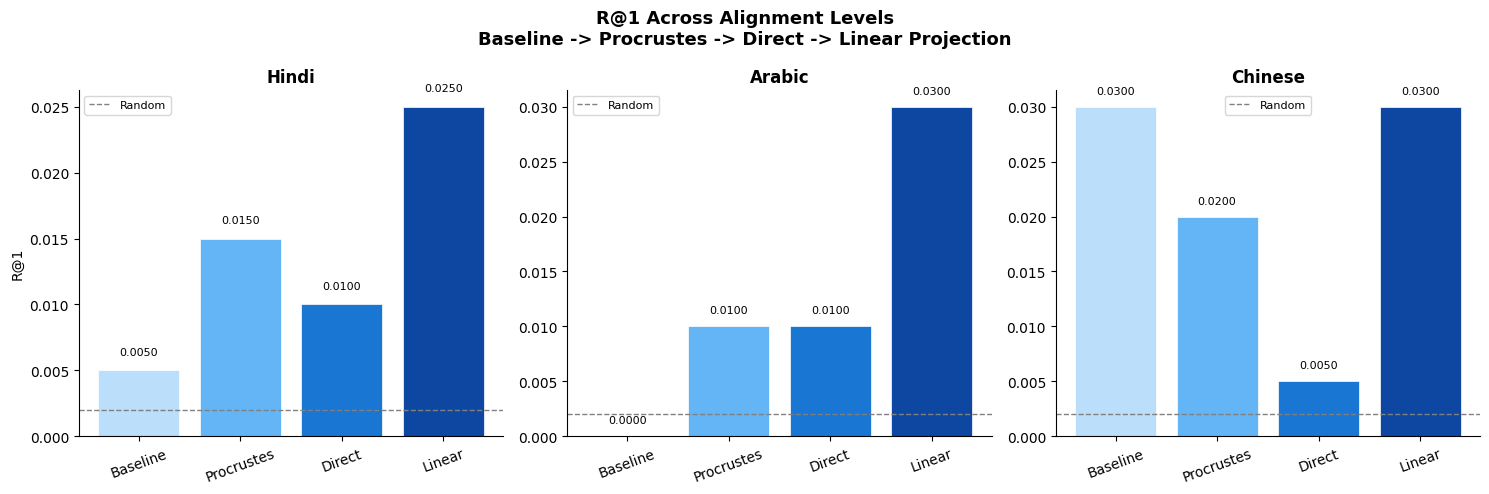

Saved: plot1_alignment_comparison.png


In [ ]:
# Plot 1: R@1 improvement across alignment levels
non_latin = ['hi', 'ar', 'zh']
methods   = ['Baseline', 'Procrustes', 'Direct', 'Linear']
method_colors = ['#BBDEFB', '#64B5F6', '#1976D2', '#0D47A1']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax_idx, code in enumerate(non_latin):
    ax   = axes[ax_idx]
    base = level1_results[code]['baseline']
    vals = [
        base['R@1'],
        level1_results[code]['procrustes']['R@1'],
        level2_results[code]['direct']['R@1'],
        level3_results[code]['best']['R@1'],
    ]

    bars = ax.bar(methods, vals, color=method_colors, edgecolor='white',
                  linewidth=0.5)
    ax.axhline(1/500, color='gray', linestyle='--',
               linewidth=1, label='Random')
    ax.set_title(LANGUAGES[code], fontweight='bold', fontsize=12)
    ax.set_ylabel('R@1' if ax_idx == 0 else '')
    ax.tick_params(axis='x', rotation=20)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8)

    # Annotate bars with values
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('R@1 Across Alignment Levels\n'
             'Baseline -> Procrustes -> Direct -> Linear Projection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ALIGN_DIR, 'plot1_alignment_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot1_alignment_comparison.png')

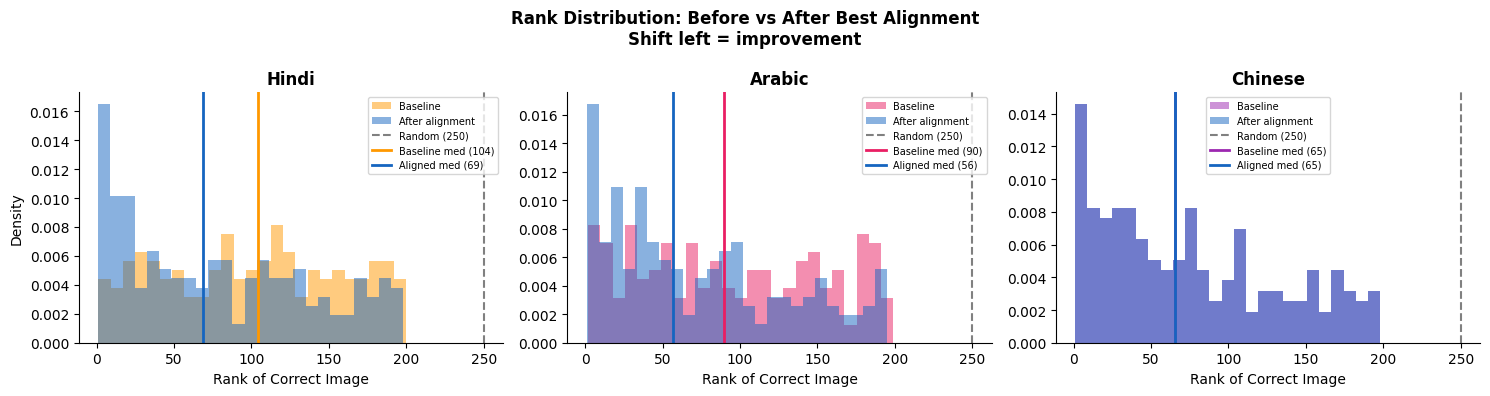

Saved: plot2_rank_distribution.png


In [ ]:
# Plot 2: Rank distribution before and after best alignment
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_idx, code in enumerate(non_latin):
    ax   = axes[ax_idx]
    base = level1_results[code]['baseline']['ranks']
    best = level3_results[code]['best']['ranks']

    ax.hist(base, bins=25, alpha=0.5, color=COLORS[code],
            label='Baseline', density=True)
    ax.hist(best, bins=25, alpha=0.5, color='#1565C0',
            label='After alignment', density=True)
    ax.axvline(250, color='gray', linestyle='--',
               linewidth=1.5, label='Random (250)')
    ax.axvline(float(np.median(base)), color=COLORS[code],
               linestyle='-', linewidth=2,
               label=f'Baseline med ({int(np.median(base))})')
    ax.axvline(float(np.median(best)), color='#1565C0',
               linestyle='-', linewidth=2,
               label=f'Aligned med ({int(np.median(best))})')

    ax.set_title(LANGUAGES[code], fontweight='bold')
    ax.set_xlabel('Rank of Correct Image')
    ax.set_ylabel('Density' if ax_idx == 0 else '')
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Rank Distribution: Before vs After Best Alignment\n'
             'Shift left = improvement',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ALIGN_DIR, 'plot2_rank_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot2_rank_distribution.png')

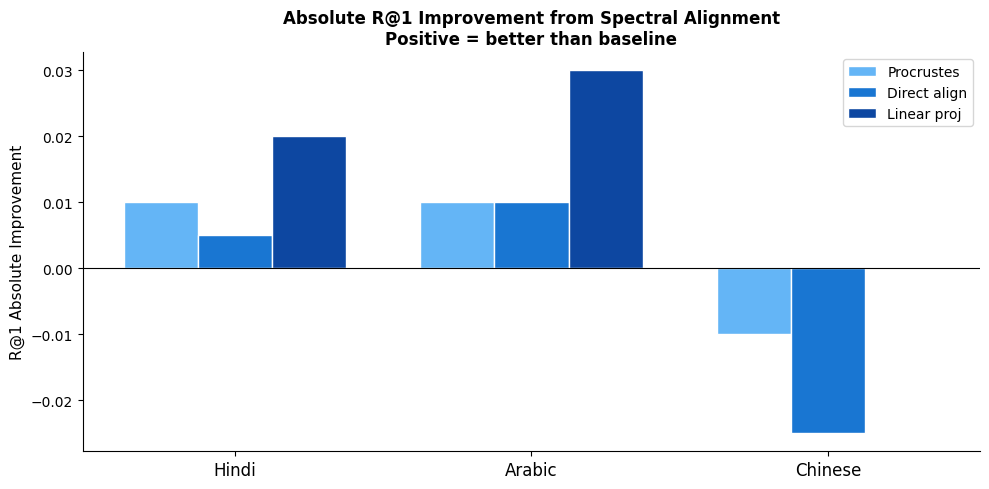

Saved: plot3_improvement_summary.png


In [ ]:
# Plot 3: Relative improvement summary
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(non_latin))
width = 0.25
lang_names = [LANGUAGES[c] for c in non_latin]

proc_imps   = [level1_results[c]['procrustes']['R@1'] -
               level1_results[c]['baseline']['R@1']   for c in non_latin]
direct_imps = [level2_results[c]['direct']['R@1'] -
               level2_results[c]['baseline']['R@1']   for c in non_latin]
linear_imps = [level3_results[c]['best']['R@1'] -
               level3_results[c]['baseline']['R@1']   for c in non_latin]

ax.bar(x - width, proc_imps,   width, label='Procrustes',
       color='#64B5F6', edgecolor='white')
ax.bar(x,         direct_imps, width, label='Direct align',
       color='#1976D2', edgecolor='white')
ax.bar(x + width, linear_imps, width, label='Linear proj',
       color='#0D47A1', edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(lang_names, fontsize=12)
ax.set_ylabel('R@1 Absolute Improvement', fontsize=11)
ax.set_title('Absolute R@1 Improvement from Spectral Alignment\n'
             'Positive = better than baseline',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(ALIGN_DIR, 'plot3_improvement_summary.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot3_improvement_summary.png')

In [ ]:
# ── Install ───────────────────────────────────────────────────────────────────
!pip install indic-transliteration -q
!pip install git+https://github.com/openai/CLIP.git -q
!pip install datasets -q

  Preparing metadata (setup.py) ... done


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import clip
import torch
import numpy as np
import io
import os
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from datasets import load_dataset
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
device = 'cpu'
print('Ready')

Ready


In [ ]:
# ── Mount Drive ───────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR   = '/content/drive/MyDrive/clip_audit'
PHASE2_DIR = os.path.join(BASE_DIR, 'phase2')
ALIGN_DIR  = os.path.join(BASE_DIR, 'spectral_alignment')
os.makedirs(ALIGN_DIR, exist_ok=True)

LANGUAGES = {
    'en': 'English',
    'es': 'Spanish',
    'hi': 'Hindi',
    'ar': 'Arabic',
    'zh': 'Chinese'
}
print('Config set')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config set


In [ ]:
# ── Load embeddings ───────────────────────────────────────────────────────────
print('Loading embeddings...')
text_embs = {}
for code in LANGUAGES:
    text_embs[code] = np.load(
        os.path.join(PHASE2_DIR, f'text_embs_{code}.npy')
    )
    print(f'  {LANGUAGES[code]}: {text_embs[code].shape}')

image_embs = np.load(os.path.join(PHASE2_DIR, 'image_embeddings.npy'))
print(f'  Images: {image_embs.shape}')

Loading embeddings...
  English: (500, 512)
  Spanish: (500, 512)
  Hindi: (500, 512)
  Arabic: (500, 512)
  Chinese: (500, 512)
  Images: (500, 512)


In [ ]:
# ── Load Hindi captions from XM3600 ──────────────────────────────────────────
print('Loading Hindi captions...')
hi_ds = load_dataset('floschne/xm3600', split='hi')
captions = {'hi': [hi_ds[i]['captions'][0] for i in range(500)]}
print(f'Loaded {len(captions["hi"])} Hindi captions')
print(f'Sample: {captions["hi"][0]}')

Loading Hindi captions...


README.md: 0.00B [00:00, ?B/s]

data/ar-00000-of-00001.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

data/bn-00000-of-00001.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

data/cs-00000-of-00001.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

...

Generating tr split:   0%|          | 0/3600 [00:00<?, ? examples/s]

Generating uk split:   0%|          | 0/3600 [00:00<?, ? examples/s]

Generating vi split:   0%|          | 0/3600 [00:00<?, ? examples/s]

Generating zh split:   0%|          | 0/3600 [00:00<?, ? examples/s]

Loaded 500 Hindi captions
Sample: ज़मीन पर छोटे पौधों के बीच दो मुर्गियों का दृश्य है


In [ ]:
# ── Train/test split ──────────────────────────────────────────────────────────
N = len(image_embs)
train_idx, test_idx = train_test_split(
    np.arange(N), test_size=0.4, random_state=42
)
print(f'Train: {len(train_idx)} | Test: {len(test_idx)}')

Train: 300 | Test: 200


In [ ]:
# ── Helper functions ──────────────────────────────────────────────────────────
def retrieval_metrics(text_emb, image_emb, ks=[1, 5, 10]):
    N   = len(text_emb)
    sim = text_emb @ image_emb.T
    ranks = []
    for i in range(N):
        rank = np.where(np.argsort(sim[i])[::-1] == i)[0][0] + 1
        ranks.append(rank)
    ranks = np.array(ranks)
    res = {f'R@{k}': float(np.mean(ranks <= k)) for k in ks}
    res['MRR']    = float(np.mean(1.0 / ranks))
    res['median'] = float(np.median(ranks))
    res['ranks']  = ranks
    return res

def linear_projection_align(source_train, target_train,
                              source_test, alpha=1.0):
    ridge   = Ridge(alpha=alpha, fit_intercept=False)
    ridge.fit(source_train, target_train)
    W       = ridge.coef_.T
    aligned = source_test @ W
    norms   = np.linalg.norm(aligned, axis=1, keepdims=True)
    return aligned / (norms + 1e-10), W

def romanize_hindi(text):
    return transliterate(text, sanscript.DEVANAGARI, sanscript.ITRANS)

print('Functions ready')

Functions ready


In [ ]:
# ── Encode romanized Hindi with CLIP ─────────────────────────────────────────
print('Loading CLIP...')
clip_model, preprocess = clip.load('ViT-B/32', device=device)
clip_model.eval()

def encode_clip(texts, batch_size=32):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch  = texts[i:i+batch_size]
        tokens = clip.tokenize(batch, truncate=True)
        with torch.no_grad():
            embs = clip_model.encode_text(tokens)
            embs = embs / embs.norm(dim=-1, keepdim=True)
        all_embs.append(embs.numpy())
    return np.vstack(all_embs)

print('Romanizing Hindi captions...')
roman_hi_caps = [romanize_hindi(c) for c in captions['hi']]
roman_hi_embs = encode_clip(roman_hi_caps)
print(f'Romanized embeddings shape: {roman_hi_embs.shape}')
print(f'Sample: {roman_hi_caps[0]}')

del clip_model
print('Done')

Loading CLIP...
Romanizing Hindi captions...
Romanized embeddings shape: (500, 512)
Sample: zamIna para ChoTe paudhoM ke bIcha do murgiyoM kA dRRishya hai
Done


In [ ]:
# ── Four-way comparison ───────────────────────────────────────────────────────
best_alpha = 1.0  # from earlier experiments

# 1. Baseline
base = retrieval_metrics(
    text_embs['hi'][test_idx],
    image_embs[test_idx]
)

# 2. Romanization only
roman_only = retrieval_metrics(
    roman_hi_embs[test_idx],
    image_embs[test_idx]
)

# 3. Linear projection only — on Devanagari
aligned_deva, _ = linear_projection_align(
    text_embs['hi'][train_idx],
    image_embs[train_idx],
    text_embs['hi'][test_idx],
    alpha=best_alpha
)
proj_only = retrieval_metrics(aligned_deva, image_embs[test_idx])

# 4. Romanization + Linear projection
aligned_roman, W_roman = linear_projection_align(
    roman_hi_embs[train_idx],
    image_embs[train_idx],
    roman_hi_embs[test_idx],
    alpha=best_alpha
)
combo = retrieval_metrics(aligned_roman, image_embs[test_idx])

# Print results
print('=' * 68)
print('HINDI — FOUR METHOD COMPARISON')
print('=' * 68)
print(f'{"Method":<30} {"R@1":>7} {"R@5":>7} {"R@10":>7} '
      f'{"Med":>6} {"vs Base":>9}')
print('-' * 68)

methods = [
    ('Baseline (Devanagari)',     base),
    ('Romanization only',         roman_only),
    ('Linear projection only',    proj_only),
    ('Romanization + Projection', combo),
]

for label, res in methods:
    imp     = res['R@1'] - base['R@1']
    imp_str = f'{imp:+.4f}' if label != 'Baseline (Devanagari)' else '---'
    print(f'{label:<30} '
          f'{res["R@1"]:>7.4f} {res["R@5"]:>7.4f} '
          f'{res["R@10"]:>7.4f} {res["median"]:>6.0f} {imp_str:>9}')

print('=' * 68)
print(f'Random baseline: R@1=0.0020, median=250')

HINDI — FOUR METHOD COMPARISON
Method                             R@1     R@5    R@10    Med   vs Base
--------------------------------------------------------------------
Baseline (Devanagari)           0.0050  0.0250  0.0350    104       ---
Romanization only               0.0200  0.0550  0.1050     86   +0.0150
Linear projection only          0.0050  0.0350  0.0750     91   +0.0000
Romanization + Projection       0.0050  0.0450  0.0850     74   +0.0000
Random baseline: R@1=0.0020, median=250


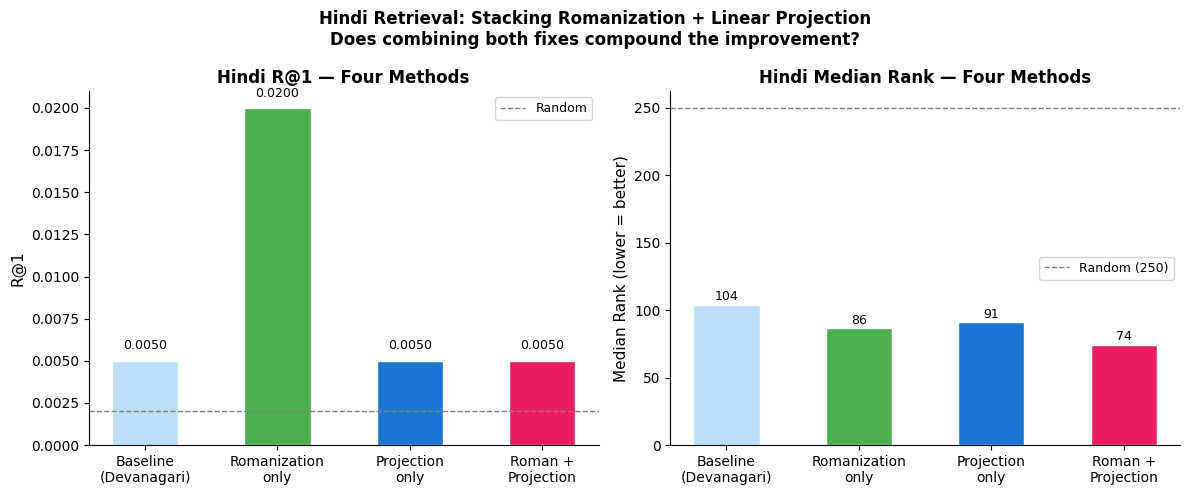

Saved: plot5_hindi_combo.png


In [ ]:
# ── Plot ──────────────────────────────────────────────────────────────────────
labels   = ['Baseline\n(Devanagari)', 'Romanization\nonly',
            'Projection\nonly', 'Roman +\nProjection']
r1_vals  = [base['R@1'], roman_only['R@1'],
            proj_only['R@1'], combo['R@1']]
med_vals = [base['median'], roman_only['median'],
            proj_only['median'], combo['median']]
colors   = ['#BBDEFB', '#4CAF50', '#1976D2', '#E91E63']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(labels, r1_vals, color=colors,
                   edgecolor='white', width=0.5)
axes[0].axhline(1/500, color='gray', linestyle='--',
                linewidth=1, label='Random')
axes[0].set_ylabel('R@1', fontsize=11)
axes[0].set_title('Hindi R@1 — Four Methods', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[0].legend(fontsize=9)
for bar, val in zip(bars, r1_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.0005, f'{val:.4f}',
                 ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(labels, med_vals, color=colors,
                    edgecolor='white', width=0.5)
axes[1].axhline(250, color='gray', linestyle='--',
                linewidth=1, label='Random (250)')
axes[1].set_ylabel('Median Rank (lower = better)', fontsize=11)
axes[1].set_title('Hindi Median Rank — Four Methods', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, med_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 1, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=9)

fig.suptitle(
    'Hindi Retrieval: Stacking Romanization + Linear Projection\n'
    'Does combining both fixes compound the improvement?',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(ALIGN_DIR, 'plot5_hindi_combo.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot5_hindi_combo.png')